In [7]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connecting to my local SQL Server instance
connection_string = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=budi;"
    "DATABASE=marketplace_analytics;"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)
conn = pyodbc.connect(connection_string)

print("Connected.")

Connected.


C:\Users\setyo\AppData\Local\Temp\ipykernel_19732\1021860147.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_b2b = pd.read_sql(sql=b2b_query,
C:\Users\setyo\AppData\Local\Temp\ipykernel_19732\1021860147.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_b2b,


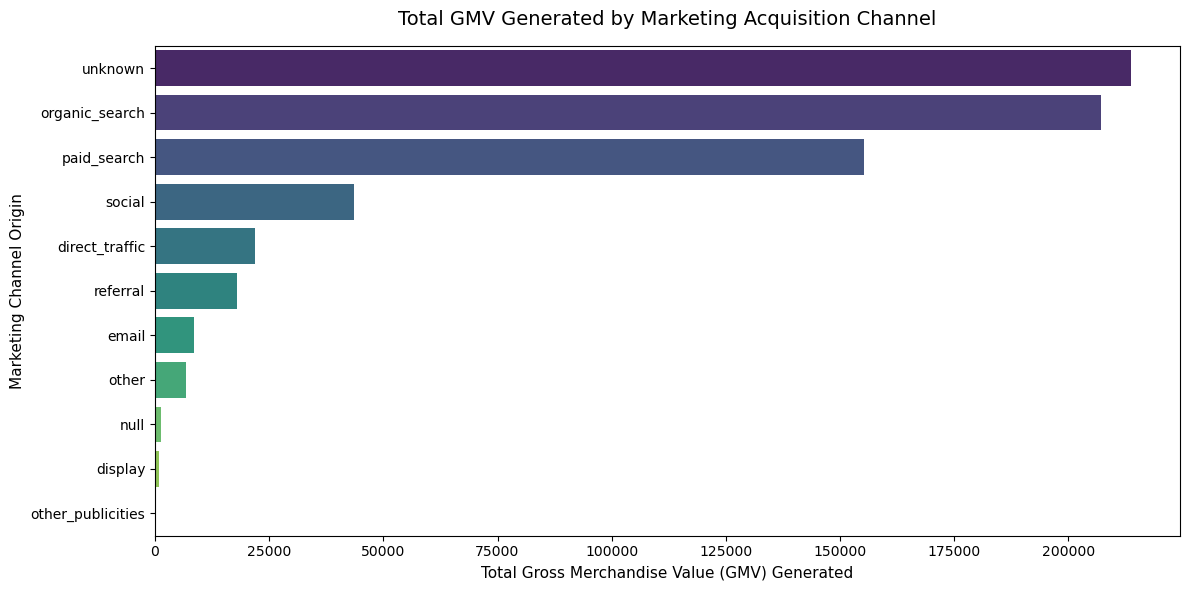

In [8]:
# Pulling and visualizing B2B marketing channel performance
b2b_query = """
WITH seller_gmv_aggregate AS (
    SELECT
        seller_id,
        SUM(item_price) AS total_seller_gmv
    FROM analytics.fact_orders
    GROUP BY seller_id
)
SELECT
    ds.marketing_channel,
    COUNT(DISTINCT ds.mql_id) AS total_marketing_qualified_leads,
    COUNT(DISTINCT ds.seller_id) AS total_converted_sellers,
    ROUND(100.0 * COUNT(DISTINCT ds.seller_id) / COUNT(DISTINCT ds.mql_id), 2) AS conversion_rate_pct,
    ROUND(AVG(CAST(DATEDIFF(day, ds.lead_generation_date, ds.closed_won_timestamp) AS FLOAT)), 1) AS avg_days_to_close,
    ROUND(SUM(gmv.total_seller_gmv), 2) AS total_gmv_generated,
    ROUND(SUM(gmv.total_seller_gmv) / COUNT(DISTINCT ds.mql_id), 2) AS revenue_yield_per_mql
FROM analytics.dim_sellers AS ds
LEFT JOIN seller_gmv_aggregate AS gmv ON ds.seller_id = gmv.seller_id
WHERE ds.marketing_channel IS NOT NULL
GROUP BY ds.marketing_channel
ORDER BY total_gmv_generated DESC;
"""

# Extracting data into pandas dataframe
df_b2b = pd.read_sql(sql=b2b_query, 
                     con=conn)

# Cleaning null or NaN values
df_b2b['total_gmv_generated'] = df_b2b['total_gmv_generated'].fillna(0)
df_b2b = df_b2b.sort_values(by='total_gmv_generated', 
                            ascending=False)

# Plotting B2B channel performance chart
plt.figure(figsize=(12, 6))
sns.barplot(data=df_b2b, 
            x='total_gmv_generated', 
            y='marketing_channel', 
            palette='viridis')
plt.title('Total GMV Generated by Marketing Acquisition Channel', 
          fontsize=14, 
          pad=15)
plt.xlabel('Total Gross Merchandise Value (GMV) Generated', 
           fontsize=11)
plt.ylabel('Marketing Channel Origin', 
           fontsize=11)
plt.tight_layout()
plt.show()

C:\Users\setyo\AppData\Local\Temp\ipykernel_19732\2082922868.py:39: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_b2c = pd.read_sql(sql=b2c_query,


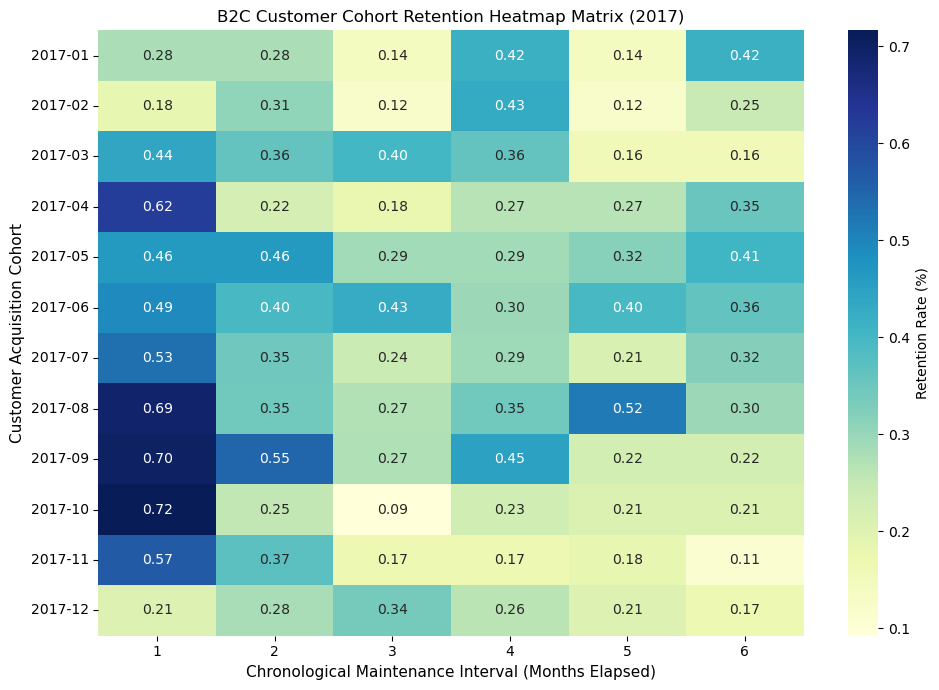

In [ ]:
# Building the B2C customer cohort retention heatmap
b2c_query= """
WITH customer_purchases AS (
    SELECT
        dc.customer_unique_id,
        fo.order_purchase_timestamp,
        DATETRUNC(month, fo.order_purchase_timestamp) AS purchase_month
    FROM analytics.fact_orders AS fo 
    JOIN analytics.dim_customers AS dc ON fo.customer_id = dc.customer_id
    WHERE fo.order_status = 'delivered'
),
cohort_stamps AS (
    SELECT
        customer_unique_id,
        purchase_month,
        MIN(purchase_month) OVER(PARTITION BY customer_unique_id) AS cohort_month
    FROM customer_purchases
),
cohort_intervals AS (
    SELECT DISTINCT 
        customer_unique_id,
        cohort_month,
        DATEDIFF(month, cohort_month, purchase_month) AS month_index
    FROM cohort_stamps
)
SELECT 
    FORMAT(cohort_month, 'yyyy-MM') AS cohort_vintage,
    month_index,
    COUNT(customer_unique_id) AS user_count
FROM cohort_intervals
-- Focusing only on 2017 to build a readable heatmap chart
WHERE cohort_month BETWEEN '2017-01-01' AND '2017-12-31'
GROUP BY 
    cohort_month,
    month_index;
"""

# Extracting data and reshaping into pivot grid
df_b2c = pd.read_sql(sql=b2c_query, 
                     con=conn)
pivot_matrix = df_b2c.pivot(index='cohort_vintage', 
                            columns='month_index', 
                            values='user_count').fillna(0)

# Calculating retention percentages relative to month 0 cohort baseline sizes
retention_heatmap = pivot_matrix.div(other=pivot_matrix[0], 
                                     axis=0) * 100
retention_heatmap = retention_heatmap[[1, 2, 3, 4, 5, 6]]

# Generating cohort heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(data=retention_heatmap, 
            annot=True, 
            fmt=".2f", 
            cmap="YlGnBu", 
            cbar_kws={'label': 'Retention Rate (%)'})
plt.title('B2C Customer Cohort Retention Heatmap Matrix (2017)')
plt.xlabel('Chronological Maintenance Interval (Months Elapsed)', 
           fontsize=11)
plt.ylabel('Customer Acquisition Cohort', 
           fontsize=11)
plt.tight_layout()
plt.show()


In [ ]:
conn.close()